# [Step 6 - CharacterTextSplitter] Fixed-size cuts with a separator

**MLCourse - Agentic AI - Module 06: Chunking Strategies**

> Stage in the capstone: stage 2 CHUNK: chunk quality decides retrieval accuracy in the capstone.

## What you'll learn

- the mechanics: one separator splits text into pieces, then pieces are packed
  up to `chunk_size` with `chunk_overlap` of shared context
- the overlap arithmetic (stride = size - overlap) on real numbers
- how to MEASURE chunk quality: size spread plus a mid-sentence-cut rate
- why a missing separator makes this splitter fail loudly - or silently badly

---

In [1]:
# =====================================================================
# CELL 1 - SHARED SETUP: imports, track discovery, download-once cache
# =====================================================================

# --- Standard library -------------------------------------------------
import os                      # file-system odds and ends
import urllib.request          # polite HTTP fetching
from pathlib import Path       # object-oriented filesystem paths

# --- Lesson-specific imports ------------------------------------------
import matplotlib.pyplot as plt                                # histograms
from langchain_community.document_loaders import TextLoader    # alice source
from langchain_text_splitters import CharacterTextSplitter     # today's tool

# ---------------------------------------------------------------------
# TRACK WALKER - resolve 03_agentic_ai by walking upward from cwd.
# ---------------------------------------------------------------------
def _find_track(start: Path) -> Path:
    """Return the absolute path of the 03_agentic_ai track root."""
    for candidate in (start, *start.parents):
        hit = candidate / "03_agentic_ai"
        if hit.is_dir():
            return hit.resolve()
    raise FileNotFoundError(
        f"No directory named 03_agentic_ai found above {start} - "
        "run this notebook from somewhere inside the MLCourse repo."
    )

TRACK = _find_track(Path.cwd())
DATA = TRACK / "data"
DATA.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# DOWNLOAD-ONCE HELPERS - fetch once, cache under DATA, reuse forever.
# ---------------------------------------------------------------------
def get_bytes(fname: str, url: str) -> bytes:
    """Return the file's bytes, downloading only on the very first call."""
    target = DATA / fname
    if target.exists() and target.stat().st_size > 0:
        payload = target.read_bytes()
        print(f"[cache] {fname}: {len(payload):,} bytes")
        return payload
    print(f"[fetch] {url}")
    request = urllib.request.Request(url, headers={"User-Agent": "MLCourse/1.0"})
    with urllib.request.urlopen(request, timeout=60) as response:
        payload = response.read()
    target.write_bytes(payload)
    print(f"[saved] {fname}: {len(payload):,} bytes")
    return payload

def get_text(fname: str, url: str, encoding: str = "utf-8-sig") -> str:
    """get_bytes + decode; drops a BOM if present."""
    return get_bytes(fname, url).decode(encoding, errors="replace")

# Matplotlib inline guard (Jupyter-only API wrapped for script safety).
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

# =====================================================================
# ANALYSIS TOOLBOX - reused verbatim in every chunking notebook so the
# numbers across notebooks are directly comparable.
# =====================================================================
def to_ascii(text: str) -> str:
    """Console-safe view of book text: curly glyphs become '?'."""
    return text.encode("ascii", errors="replace").decode("ascii")

# Gutenberg typography uses curly quotes/apostrophes; normalise them so
# the boundary heuristic can stay pure ASCII.
_CURLY = {"\u2019": "'", "\u201d": '"', "\u201c": '"', "\u2018": "'"}
SENTENCE_ENDS = tuple(".!?\"')")

def ends_naturally(chunk: str) -> bool:
    """Heuristic: a CLEAN chunk tail ends in sentence-final punctuation."""
    tail = chunk.rstrip()
    if not tail:
        return True
    tail = "".join(_CURLY.get(ch, ch) for ch in tail[-3:])   # curly -> ASCII
    return tail.endswith(SENTENCE_ENDS)

def cut_report(chunks):
    """Return (offending chunks, percent cut mid-sentence)."""
    bad = [c for c in chunks if not ends_naturally(c)]
    pct = 100.0 * len(bad) / max(len(chunks), 1)
    return bad, pct

def describe_sizes(chunks, label):
    """Print min/mean/max character sizes; return the size list."""
    sizes = [len(c) for c in chunks]
    mean = sum(sizes) / max(len(sizes), 1)
    print(f"{label}: {len(chunks)} chunks | "
          f"min={min(sizes)} mean={mean:.0f} max={max(sizes)} chars")
    return sizes

def plot_hist(sizes, title):
    """Histogram of chunk sizes - shape matters more than any single number."""
    plt.figure(figsize=(8, 3))
    plt.hist(sizes, bins=30, color="#4c72b0", edgecolor="white")
    plt.title(title)
    plt.xlabel("chunk size (characters)")
    plt.ylabel("number of chunks")
    plt.tight_layout()
    plt.show()

def show_first_chunks(chunks, n=3):
    """Print the first n chunks raw between clear fences."""
    for i, chunk in enumerate(chunks[:n]):
        print(f"===== chunk {i} ({len(chunk)} chars) =====")
        print(to_ascii(chunk))
        print()

C:\Users\Thoyajaksha Kashyap\AppData\Local\Temp\ipykernel_38948\3418641834.py:12: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader    # alice source


## 1. WHAT it does, WHY it matters

`CharacterTextSplitter` is the dumbest cutter that still respects ONE idea
of structure. Algorithm:

1. split the WHOLE text on a single `separator` (we use `"\n\n"` - blank
   lines, i.e. paragraphs);
2. pack consecutive pieces together until adding another would exceed
   `chunk_size` characters;
3. before starting the next chunk, rewind `chunk_overlap` characters so the
   new chunk REPEATS the tail of the previous one;
4. emit the chunk.

### The overlap arithmetic (memorize this)

With `chunk_size=500`, `chunk_overlap=100`:

```text
stride = chunk_size - overlap = 400 NEW characters per chunk

text : |============================= 1200 chars =============================|
chunk0: [0 .......... 500]
chunk1:      [400 .......... 900]     <- 100-char band repeated (overlap)
chunk2:           [800 ......... 1200]

expected count ~ ceil((1200 - 100) / 400) = 3 chunks
```

WHY overlap exists: facts that straddle a cut appear COMPLETE inside at
least one chunk, so retrieval can still score that chunk highly. It is an
insurance policy against our own knife.

## 2. Load Alice and apply the splitter

Same download-once ritual as module 05: the loader stage hands us the whole
book as one Document; TODAY we finally decide the retrieval units.

In [2]:
get_bytes("alice.txt", "https://www.gutenberg.org/files/11/11-0.txt")
alice_docs = TextLoader(str(DATA / "alice.txt"), encoding="utf-8").load()
text = alice_docs[0].page_content                 # the entire novel, one string
print(f"loaded {len(text):,} characters")

splitter = CharacterTextSplitter(
    separator="\n\n",       # cut ONLY at blank lines (paragraph borders)
    chunk_size=500,         # target maximum characters per chunk
    chunk_overlap=100,      # characters re-shared with the previous chunk
    length_function=len,    # how 'length' is measured (default: characters)
)
chunks = splitter.split_text(text)

print(f"\nproduced {len(chunks)} chunks\n")
show_first_chunks(chunks, n=3)

Created a chunk of size 739, which is longer than the specified 500


Created a chunk of size 715, which is longer than the specified 500


Created a chunk of size 706, which is longer than the specified 500


Created a chunk of size 684, which is longer than the specified 500


Created a chunk of size 980, which is longer than the specified 500


...

Created a chunk of size 732, which is longer than the specified 500


Created a chunk of size 629, which is longer than the specified 500


Created a chunk of size 632, which is longer than the specified 500


Created a chunk of size 555, which is longer than the specified 500


[cache] alice.txt: 151,191 bytes
loaded 144,696 characters

produced 356 chunks

===== chunk 0 (162 chars) =====
*** START OF THE PROJECT GUTENBERG EBOOK 11 ***

[Illustration]


Alice?s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

===== chunk 1 (472 chars) =====
Contents

 CHAPTER I.     Down the Rabbit-Hole
 CHAPTER II.    The Pool of Tears
 CHAPTER III.   A Caucus-Race and a Long Tale
 CHAPTER IV.    The Rabbit Sends in a Little Bill
 CHAPTER V.     Advice from a Caterpillar
 CHAPTER VI.    Pig and Pepper
 CHAPTER VII.   A Mad Tea-Party
 CHAPTER VIII.  The Queen?s Croquet-Ground
 CHAPTER IX.    The Mock Turtle?s Story
 CHAPTER X.     The Lobster Quadrille
 CHAPTER XI.    Who Stole the Tarts?
 CHAPTER XII.   Alice?s Evidence

===== chunk 2 (336 chars) =====
CHAPTER I.
Down the Rabbit-Hole


Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her

You likely saw logger lines like
`Created a chunk of size 739, which is longer than the specified 500`.
That is the splitter CONFESSING its weakness: some regions have no blank
line within reach, the single piece exceeds the limit, and there is NO
fallback - it ships the oversized chunk with a warning. Remember those
numbers when we read the size stats next.

character(\n\n, 500, 100): 356 chunks | min=26 mean=424 max=980 chars


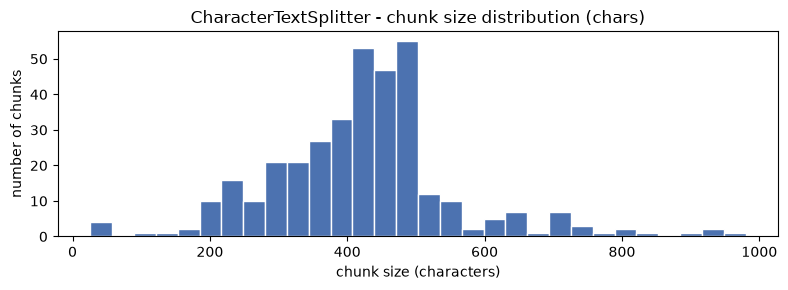


mid-sentence cut rate : 7.0%  (25 of 356 chunks do NOT end in terminal punctuation)

--- offending chunk tail ---
'erland\n\nby Lewis Carroll\n\nTHE MILLENNIUM FULCRUM EDITION 3.0\n\nContents'

--- offending chunk tail ---
'\n CHAPTER XI.    Who Stole the Tarts?\n CHAPTER XII.   Alice?s Evidence'


In [3]:
sizes = describe_sizes(chunks, "character(\\n\\n, 500, 100)")
plot_hist(sizes, "CharacterTextSplitter - chunk size distribution (chars)")

bad, pct = cut_report(chunks)
print(f"\nmid-sentence cut rate : {pct:.1f}%  "
      f"({len(bad)} of {len(chunks)} chunks do NOT end in terminal punctuation)")
for culprit in bad[:2]:                       # show evidence, not just numbers
    print("\n--- offending chunk tail ---")
    print(repr(to_ascii(culprit[-70:])))

## 3. Two failure modes you must be able to recognize

Prose WITHOUT blank lines defeats the separator assumption:

- **Mode A - the giant chunk**: zero matches means ONE piece = the whole
  text, shipped oversized with a warning. Size discipline gone.
- **Mode B - the single-character fallback**: setting `separator=""` makes
  every character a piece; packing then produces uniform windows that cut
  WORDS apart constantly. Granularity gone.

Both demos below run on a squashed slice (blank lines removed) to prove
neither mode knows what a sentence is.

In [4]:
squashed = " ".join(text[:3000].split())      # kill ALL blank-line structure

# Mode A: no separator match anywhere.
mode_a = CharacterTextSplitter(separator="\n\n", chunk_size=500,
                               chunk_overlap=100).split_text(squashed)
print(f"MODE A  chunks={len(mode_a)}  "
      f"sizes={[len(c) for c in mode_a]}  <- limit ignored!")

# Mode B: empty separator -> per-character pieces -> arbitrary word cuts.
try:
    mode_b = CharacterTextSplitter(separator="", chunk_size=200,
                                   chunk_overlap=20).split_text(squashed)
    print(f"\nMODE B  chunks={len(mode_b)} (uniform ~200-char windows)")
    print("--- a window that slices straight through words ---")
    print(repr(to_ascii(mode_b[3])))
except ValueError as err:
    print(f"MODE B refused by this version ({err}); the lesson stands: "
          "single-character granularity destroys word boundaries.")

MODE A  chunks=1  sizes=[2934]  <- limit ignored!

MODE B  chunks=17 (uniform ~200-char windows)
--- a window that slices straight through words ---
'ts? CHAPTER XII. Alice?s Evidence CHAPTER I. Down the Rabbit-Hole Alice was beginning to get very tired of sitting by her sister on the bank, and of having nothing to do: once or twice she had peeped'


## Takeaway

**CharacterTextSplitter buys simplicity with fragility: great when your
text reliably contains your separator (paragraphs!), dangerous when it
does not - oversized chunks upstream, word-shredding downstream. Always
verify the separator EXISTS before trusting the sizes.**

## Summary

- Mechanics: split once on the separator, pack to `chunk_size`, rewind by
  `chunk_overlap`; stride = 500 - 100 = 400 fresh chars/chunk here.
- On Alice: hundreds of chunks averaging well under target, but with
  overshoots up to ~980 chars - the logged warnings made that visible.
- Boundary audit: only a small minority of chunks cut mid-sentence,
  because paragraph tails usually end sentences.
- Failure modes demonstrated live: missing separator -> giant chunk;
  empty separator -> mid-word cuts. Next notebook fixes exactly this.